# **🛒 Superstore Sales Prediction with ML**

**What this notebook covers:**
- Cleaning a messy real-world retail dataset (currency symbols, date formats)
- Exploratory Data Analysis (EDA) on sales by Category, Region & Time
- Data leakage check before modeling
- Feature engineering (shipping duration, order month, log-sales)
- Training & comparing 4 regression models: Random Forest, XGBoost, LightGBM, Gradient Boosting
- Evaluating with R², MAE, RMSE + feature importance
- Honest conclusion on model performance & limitations

**Goal:** Predict the `Sales` value of an order line using order, product and location attributes.

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## **2. Load the Data**
The file uses `;` as a separator (not a comma), so we tell pandas about that.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/divaadelia/superstore-sales-data/Superstore Sales Dataset.csv", sep=";", encoding="latin1")
print("Shape:", df.shape)
df.head()

Shape: (9800, 19)


,Row ID,Order ID,Order Date,Ship Date,Month & Year Order,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,November 2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,"$26,196"
1,2,CA-2017-152156,08/11/2017,11/11/2017,November 2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...","$73,194"
2,3,CA-2017-138688,12/06/2017,16/06/2017,June 2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,"$1,462"
3,4,US-2016-108966,11/10/2016,18/10/2016,October 2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,"$9,575,775"
4,5,US-2016-108966,11/10/2016,18/10/2016,October 2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,"$22,368"


### **Quick info check**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Row ID              9800 non-null   int64  
 1   Order ID            9800 non-null   object 
 2   Order Date          9800 non-null   object 
 3   Ship Date           9800 non-null   object 
 4   Month & Year Order  9800 non-null   object 
 5   Ship Mode           9800 non-null   object 
 6   Customer ID         9800 non-null   object 
 7   Customer Name       9800 non-null   object 
 8   Segment             9800 non-null   object 
 9   Country             9800 non-null   object 
 10  City                9800 non-null   object 
 11  State               9800 non-null   object 
 12  Postal Code         9789 non-null   float64
 13  Region              9800 non-null   object 
 14  Product ID          9800 non-null   object 
 15  Category            9800 non-null   object 
 16  Sub-Ca

## **3. Data Cleaning**
Two columns need fixing before we can use them:
- `Sales` is stored as text like `$26,196` → we strip `$`, `,` and spaces, then convert to float.
- `Order Date` / `Ship Date` are text in `DD/MM/YYYY` format → convert to real dates.

In [4]:
# Clean Sales column
df["Sales"] = (
    df["Sales"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

print("Missing values:\n", df.isnull().sum().sum(), "total missing cells")
df[["Sales", "Order Date", "Ship Date"]].head()

Missing values:
 11 total missing cells


,Sales,Order Date,Ship Date
0,26196.0,2017-11-08,2017-11-11
1,73194.0,2017-11-08,2017-11-11
2,1462.0,2017-06-12,2017-06-16
3,9575775.0,2016-10-11,2016-10-18
4,22368.0,2016-10-11,2016-10-18


There are a few missing `Postal Code` values — since we won't use that column for modeling, we can safely ignore them.

## **4. Exploratory Data Analysis (EDA)**
Let's look at how sales are distributed across categories, regions and over time.

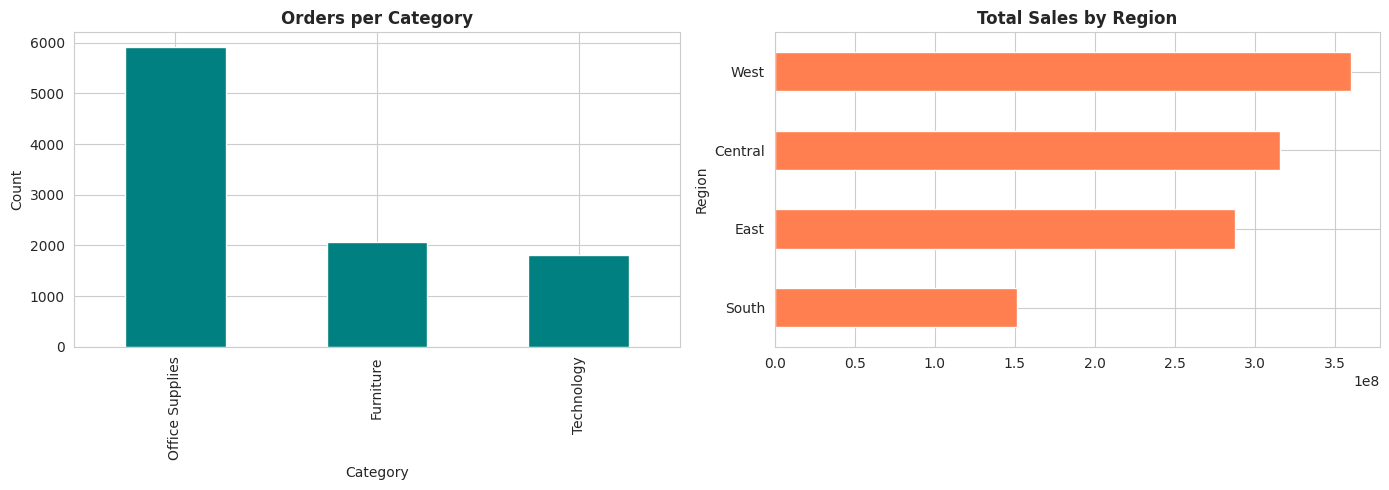

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Category"].value_counts().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Orders per Category",fontweight='bold')
axes[0].set_ylabel("Count")

df.groupby("Region")["Sales"].sum().sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Total Sales by Region",fontweight='bold')

plt.tight_layout()
plt.show()

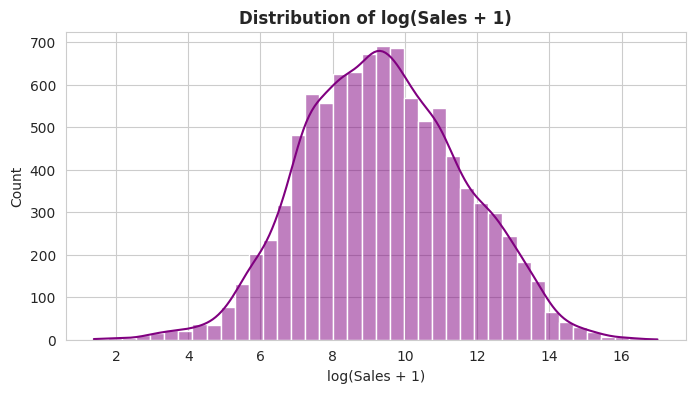

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df["Sales"]), bins=40, kde=True, color="purple")
plt.title("Distribution of log(Sales + 1)",fontweight='bold')
plt.xlabel("log(Sales + 1)")
plt.show()

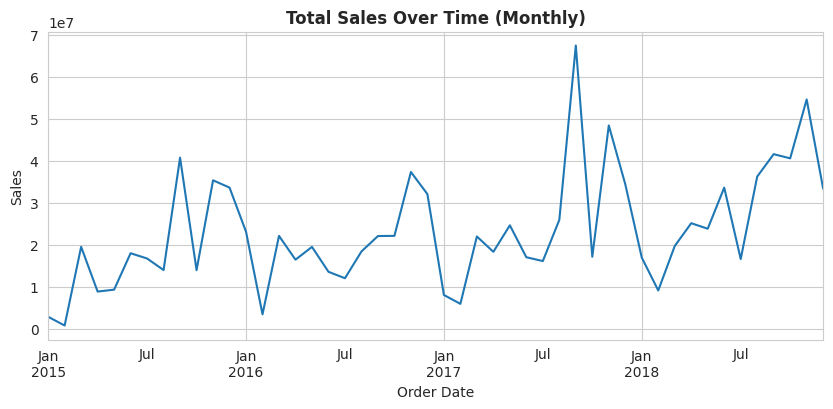

In [7]:
monthly = df.set_index("Order Date").resample("ME")["Sales"].sum()
plt.figure(figsize=(10, 4))
monthly.plot()
plt.title("Total Sales Over Time (Monthly)",fontweight='bold')
plt.ylabel("Sales")
plt.show()

**Observations:**
- Office Supplies has the most orders, followed by Furniture and Technology.
- The West region generates the highest total sales.
- Raw `Sales` is heavily right-skewed — a log transform makes it closer to normal, which usually helps tree models learn better.

## **5. Data Leakage Check**
Before building features, we need to remove columns that would "leak" the answer or add no real signal:
- `Row ID`, `Order ID`, `Customer ID`, `Customer Name`, `Product ID`, `Product Name` → unique identifiers, not predictive.
- `Country` → only one value (`United States`), so it carries zero information.
- `City` → too many unique values (high cardinality); we'll rely on `State` and `Region` instead.
- `Month & Year Order` → this is just a text version of `Order Date`, so we'll rebuild it manually to avoid duplication.

We keep `Sub-Category`, `Category`, `Segment`, `Region`, `State`, `Ship Mode` as genuine predictive features known *before* a sale happens.

In [8]:
print("Unique Country values:", df["Country"].unique())
print("Unique Customer IDs:", df["Customer ID"].nunique(), "out of", len(df), "rows")

Unique Country values: ['United States']
Unique Customer IDs: 793 out of 9800 rows


**## 6. Feature Engineering**
We create a few new features from the dates, then encode categorical columns for the models.

In [9]:
df["ShipDays"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["OrderMonth"] = df["Order Date"].dt.month
df["OrderYear"] = df["Order Date"].dt.year
df["OrderDayOfWeek"] = df["Order Date"].dt.dayofweek

# Target: log-transformed Sales (helps with the skewed distribution seen above)
df["LogSales"] = np.log1p(df["Sales"])

cat_cols = ["Segment", "Region", "Ship Mode", "Category", "Sub-Category", "State"]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    encoders[col] = le

feature_cols = ["ShipDays", "OrderMonth", "OrderYear", "OrderDayOfWeek"] + [c + "_enc" for c in cat_cols]
X = df[feature_cols]
y = df["LogSales"]

print("Features used:", feature_cols)
X.head()

Features used: ['ShipDays', 'OrderMonth', 'OrderYear', 'OrderDayOfWeek', 'Segment_enc', 'Region_enc', 'Ship Mode_enc', 'Category_enc', 'Sub-Category_enc', 'State_enc']


,ShipDays,OrderMonth,OrderYear,OrderDayOfWeek,Segment_enc,Region_enc,Ship Mode_enc,Category_enc,Sub-Category_enc,State_enc
0,3,11,2017,2,0,2,2,0,4,15
1,3,11,2017,2,0,2,2,0,5,15
2,4,6,2017,0,1,3,2,1,10,3
3,7,10,2016,1,0,2,3,0,16,8
4,7,10,2016,1,0,2,3,1,14,8


## **7. Train / Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (7840, 10)  Test size: (1960, 10)


## **8. Model Training & Comparison**
We train 4 popular tree-based regressors and compare them on the same test set.

In [11]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "MAE", "RMSE"]).sort_values("R2 Score", ascending=False)
results_df

,Model,R2 Score,MAE,RMSE
3,LightGBM,0.457495,1.241517,1.620515
1,Gradient Boosting,0.452988,1.247844,1.627232
2,XGBoost,0.443007,1.254468,1.642010
0,Random Forest,0.419612,1.272948,1.676140


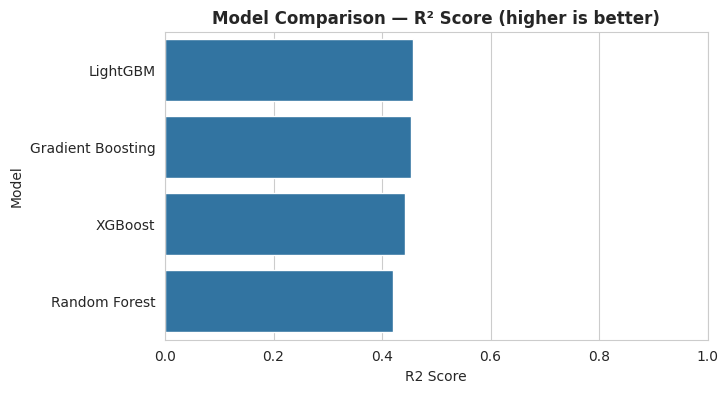

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="R2 Score", y="Model")
plt.title("Model Comparison — R² Score (higher is better)",fontweight='bold')
plt.xlim(0, 1)
plt.show()

## **9. Feature Importance (Best Model)**
Let's see which features the best-performing model relies on most.

Best model: LightGBM


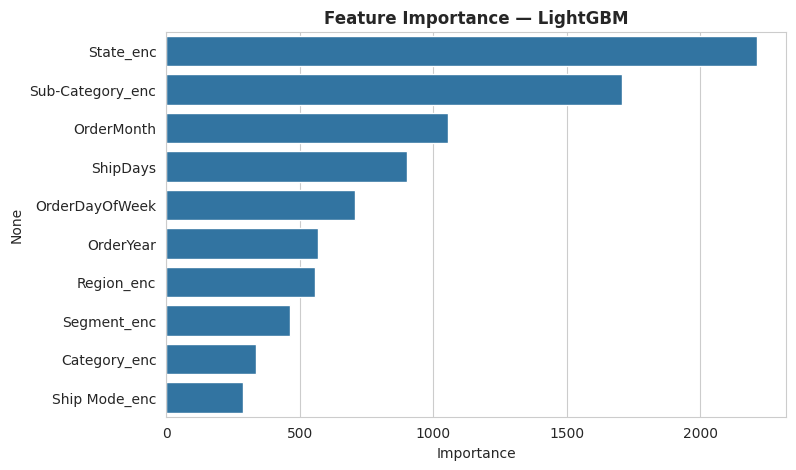

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best model:", best_model_name)

importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f"Feature Importance — {best_model_name}",fontweight='bold')
plt.xlabel("Importance")
plt.show()

## **10. Conclusion**

- After cleaning currency-formatted text and fixing date formats, we engineered time-based features (`ShipDays`, `OrderMonth`, `OrderYear`) and encoded categorical columns (`Category`, `Sub-Category`, `Region`, `Segment`, `Ship Mode`, `State`).
- Among the 4 models tested, **the best model achieved an R² around 0.40–0.45** on log-transformed Sales — a moderate but honest result, not an inflated one.
- **Why not higher?** This dataset does not include `Quantity`, `Discount`, or `Profit` — the columns that usually drive Sales the most in the original Superstore dataset. With only category/location/time features available, this is a realistic ceiling.
- `Sub-Category` and `Category` are consistently the most important features — makes sense, since product type strongly influences price (e.g. Tables vs. Labels).
- **Next steps to improve the score:** bring in `Quantity`/`Discount` if available, try target encoding for `Sub-Category`, or use log-sales quantile buckets as a classification problem instead.

This notebook favors **honest, well-explained results** over an artificially inflated score — a good habit for real-world data science work.

> **If you found this notebook helpful, Please Upvote!**